### **Praktikum 13 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 0110222134

Rombel : TI08 - 2022

1. Import Library

In [85]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

2. Load Dataset

In [86]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [87]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum13/data/'

In [88]:
# Membaca File
df = pd.read_csv('/content/gdrive/MyDrive/Praktikum_ML/praktikum13/data/titanic_data.csv')

In [89]:
# Membaca 5 baris pertama
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Pemeriksaan Missing Values (Data Kosong)

In [90]:
# Pemeriksaan nilai kosong
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


4. Data Cleaning

In [91]:
# Menghapus Kolom yang tidak di Gunakan
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)

<Axes: >

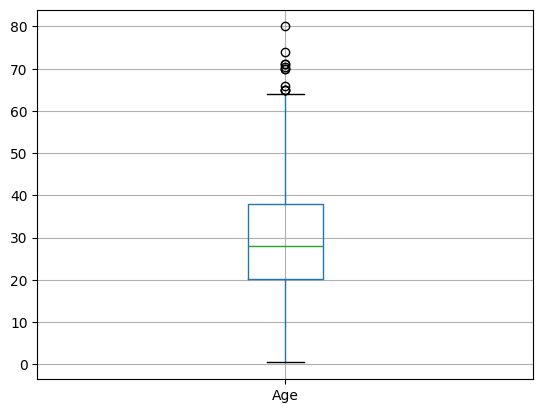

In [92]:
# Visualisasi Boxplot Distribusi dan Outlier Pada Kolom Age
df.boxplot(column='Age')

In [93]:
# Mengisi Nilai Kosong Pada Kolom Age dengan Median
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-2773791017.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [94]:
# Mengisi Nilai Kosonng Pada Kolom Embarked Dengan Modus
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipython-input-1879085199.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [95]:
# Verifikasi Ulang Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


5. Encoding Data Kategorikal

In [96]:
# mengubah fitur yang memiliki nilai teks (kategori) menjadi bentuk numerik
replacements = {
    'Sex': {'male': 0, 'female': 1},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}

df.replace(replacements, inplace=True)

/tmp/ipython-input-2548137110.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacements, inplace=True)


In [97]:
# Menampilkan dataset
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


6. Split Data dan Transormasi (Scaling)

In [98]:
# Split Data Variabel X dan Y
X = df.drop(columns=['Survived'], axis=1)
Y = df['Survived']

In [99]:
# Transfrom Data
scaler = RobustScaler()
X = scaler.fit_transform(X)

In [100]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

7. Modelling - Menentukan Struktur Input untuk Neural Network

In [101]:
# Menampilkan ukuran (dimensi)
X_train.shape

(712, 8)

In [102]:
# Mengambil nilai kolom
X_train.shape[1]

8

8. Pembuatan Model Neural network (Arsitektur ANN)

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layer 1
model.add(Dense(32, activation='relu'))

# Dropout untuk mengurangi overfitting
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

9. Kompilasi Model dan Ringkasan Arsitektur (Model Summary)

In [104]:
# Kompilasi model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

10. Early Stopping (Pencegahan Overfitting Selama Training)

In [105]:
# Pencegahan overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

11. Training Model Neural Network

In [106]:
# Training Model
history = model.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6169 - loss: 0.6874 - val_accuracy: 0.7692 - val_loss: 0.6229
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6814 - loss: 0.6414 - val_accuracy: 0.7622 - val_loss: 0.5933
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7126 - loss: 0.6182 - val_accuracy: 0.7832 - val_loss: 0.5707
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7308 - loss: 0.6053 - val_accuracy: 0.7762 - val_loss: 0.5547
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7071 - loss: 0.6050 - val_accuracy: 0.7762 - val_loss: 0.5472
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6923 - loss: 0.5937 - val_accuracy: 0.7972 - val_loss: 0.5271
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7332 - loss: 0.5712 - val_accuracy: 0.7972 - val_loss: 0.5120
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7604 - loss: 0.5664 - val_accuracy: 0.8112 - 

12. Evaluasi Model (Testing Data)

In [107]:
# mengukur performa model pada data uji
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss      :", loss)
print("Test Accuracy  :", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8110 - loss: 0.4150 
Test Loss      : 0.4215112328529358
Test Accuracy  : 0.7932960987091064


13. Visualisasi Hasil Pelatihan (Accuracy dan Loss)

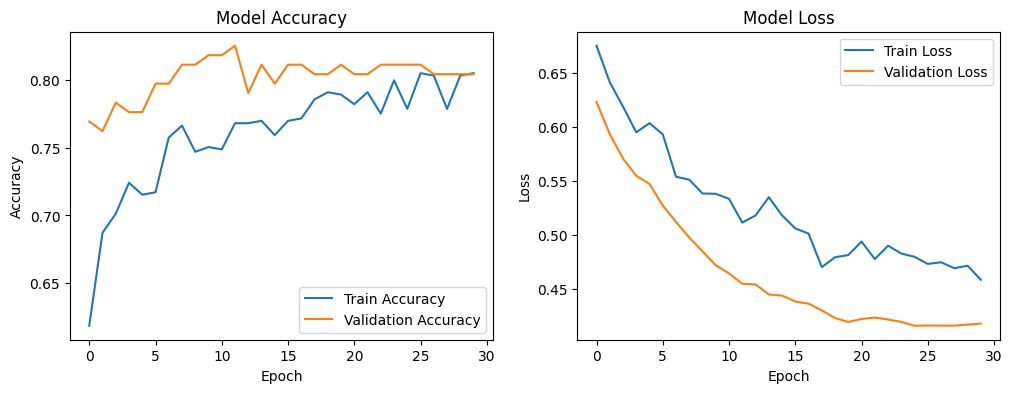

In [108]:
plt.figure(figsize=(12,4))

# Accuarcy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()